# Split Stability Audit

**Purpose:** Evaluate whether the CLEAN pipeline capture-level splitting strategy produces stable and reliable train/validation/test partitions under class imbalance.

This notebook is designed as a formal methodological audit suitable for inclusion in a thesis appendix.
It is fully reproducible and runs end-to-end without manual edits.

---

In [1]:
# -- Imports & setup --------------------------------------------------------
from __future__ import annotations

import sys, os, warnings, textwrap, io, contextlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make project importable
REPO = Path(os.getcwd()).resolve()
if REPO.name == "notebooks":
    REPO = REPO.parent
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", font_scale=1.1)

FEATURES_PATH = REPO / "artifacts" / "clean_pipeline" / "features.parquet"
REPORT_DIR    = REPO / "artifacts" / "clean_pipeline"

split_order = {"train": 0, "val": 1, "test": 2}

print(f"Repo root : {REPO}")
print(f"Features  : {FEATURES_PATH}")
print(f"Exists    : {FEATURES_PATH.exists()}")

Repo root : C:\Users\scoti\PycharmProjects\ai-vpn-firewall
Features  : C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\clean_pipeline\features.parquet
Exists    : True


---
## Section 1 — Load dataset

In [2]:
# -- Load features.parquet --------------------------------------------------
if not FEATURES_PATH.exists():
    raise FileNotFoundError(
        f"Missing: {FEATURES_PATH}\n"
        "Run the CLEAN pipeline first:\n"
        "  python -m src.clean_pipeline.run_pipeline\n"
        "or\n"
        "  from src.clean_pipeline.run_pipeline import run_clean_pipeline\n"
        "  run_clean_pipeline()"
    )

df = pd.read_parquet(FEATURES_PATH)

# Verify required columns
REQUIRED = ["flow_id", "capture_id", "dataset", "label", "split"]
missing = [c for c in REQUIRED if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

print(f"Number of flows    : {len(df):,}")
print(f"Number of captures : {df['capture_id'].nunique():,}")
print(f"Number of datasets : {df['dataset'].nunique()}")
print(f"Datasets           : {sorted(df['dataset'].unique())}")
print()

# Class balance overall
overall = df["label"].value_counts().sort_index()
print("Class balance (overall):")
for lbl, cnt in overall.items():
    tag = "VPN" if lbl == 1 else "non-VPN"
    print(f"  label={lbl} ({tag}): {cnt:>8,}  ({cnt/len(df)*100:.2f}%)")
print()

# Class balance per dataset
print("Class balance per dataset:")
for ds in sorted(df["dataset"].unique()):
    sub = df[df["dataset"] == ds]
    vpn = (sub["label"] == 1).sum()
    nonvpn = (sub["label"] == 0).sum()
    print(f"  {ds:20s}  total={len(sub):>7,}  VPN={vpn:>7,} ({vpn/len(sub)*100:.1f}%)  non-VPN={nonvpn:>7,} ({nonvpn/len(sub)*100:.1f}%)")

Number of flows    : 72,612
Number of captures : 340
Number of datasets : 3
Datasets           : ['iscx', 'usbvpn', 'vnat']

Class balance (overall):
  label=0 (non-VPN):   60,839  (83.79%)
  label=1 (VPN):   11,773  (16.21%)

Class balance per dataset:
  iscx                  total= 11,801  VPN=  2,943 (24.9%)  non-VPN=  8,858 (75.1%)
  usbvpn                total= 52,704  VPN=  8,456 (16.0%)  non-VPN= 44,248 (84.0%)
  vnat                  total=  8,107  VPN=    374 (4.6%)  non-VPN=  7,733 (95.4%)


---
## Section 2 — Flow-level split audit

In [3]:
# -- Flow-level split statistics --------------------------------------------
flow_stats = (
    df.groupby(["dataset", "split"])
    .agg(
        n_flows=("label", "size"),
        vpn_flows=("label", "sum"),
        n_captures=("capture_id", "nunique"),
    )
    .reset_index()
)
flow_stats["nonvpn_flows"] = flow_stats["n_flows"] - flow_stats["vpn_flows"]
flow_stats["vpn_ratio"] = flow_stats["vpn_flows"] / flow_stats["n_flows"]
flow_stats = flow_stats[["dataset", "split", "n_flows", "vpn_flows", "nonvpn_flows", "vpn_ratio", "n_captures"]]

# Order splits logically
flow_stats["_order"] = flow_stats["split"].map(split_order)
flow_stats = flow_stats.sort_values(["dataset", "_order"]).drop(columns="_order").reset_index(drop=True)

display(flow_stats)
print()
print(flow_stats.to_string(index=False))

,dataset,split,n_flows,vpn_flows,nonvpn_flows,vpn_ratio,n_captures
0,iscx,train,8260,2059,6201,0.249274,123
1,iscx,val,1769,440,1329,0.248728,7
2,iscx,test,1772,444,1328,0.250564,10
3,usbvpn,train,50153,5905,44248,0.117740,24
4,usbvpn,val,1282,1282,0,1.000000,3
5,usbvpn,test,1269,1269,0,1.000000,8
6,vnat,train,5675,262,5413,0.046167,86
7,vnat,val,1217,57,1160,0.046836,6
8,vnat,test,1215,55,1160,0.045267,73



dataset split  n_flows  vpn_flows  nonvpn_flows  vpn_ratio  n_captures
   iscx train     8260       2059          6201   0.249274         123
   iscx   val     1769        440          1329   0.248728           7
   iscx  test     1772        444          1328   0.250564          10
 usbvpn train    50153       5905         44248   0.117740          24
 usbvpn   val     1282       1282             0   1.000000           3
 usbvpn  test     1269       1269             0   1.000000           8
   vnat train     5675        262          5413   0.046167          86
   vnat   val     1217         57          1160   0.046836           6
   vnat  test     1215         55          1160   0.045267          73


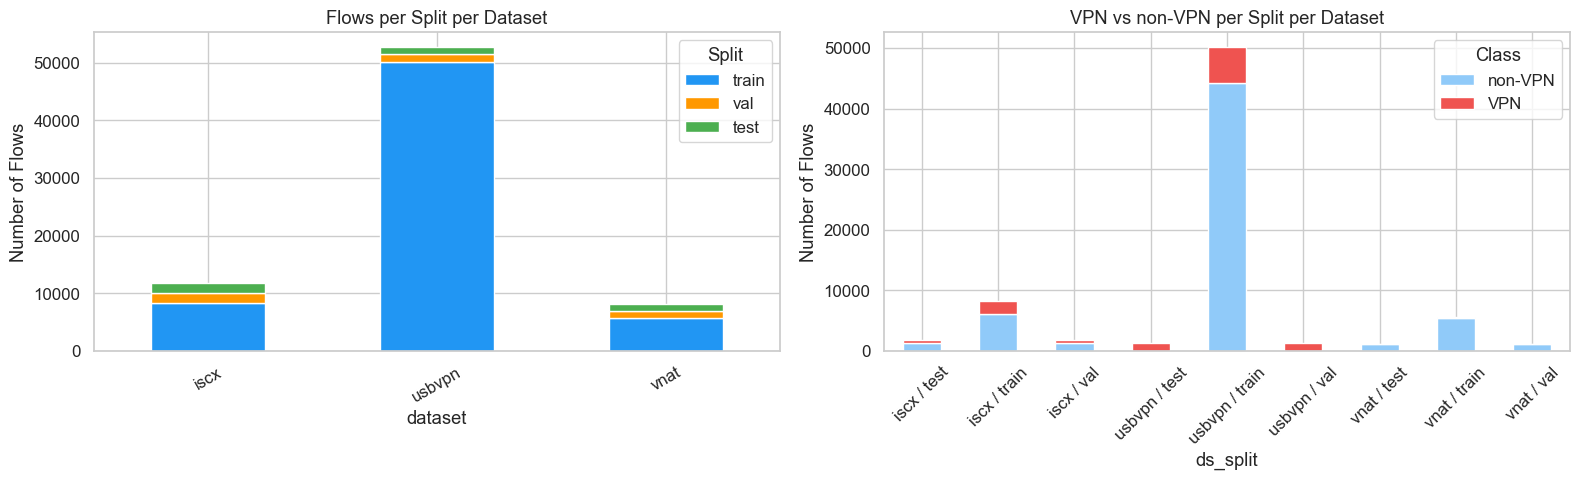


Interpretation: If VPN ratios are approximately equal across splits
  within each dataset, the splitting strategy preserves class balance.


In [4]:
# -- Plot: flows per split per dataset (stacked) ---------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Stacked bar: total flows per split per dataset
pivot_flows = flow_stats.pivot(index="dataset", columns="split", values="n_flows").reindex(columns=["train", "val", "test"])
pivot_flows.plot.bar(stacked=True, ax=axes[0], color=["#2196F3", "#FF9800", "#4CAF50"])
axes[0].set_title("Flows per Split per Dataset")
axes[0].set_ylabel("Number of Flows")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(title="Split")

# Stacked bar: VPN vs non-VPN per split per dataset
vpn_split = (
    df.assign(class_label=df["label"].map({1: "VPN", 0: "non-VPN"}))
    .groupby(["dataset", "split", "class_label"])
    .size()
    .reset_index(name="count")
)
vpn_split["ds_split"] = vpn_split["dataset"] + " / " + vpn_split["split"]
pivot_class = vpn_split.pivot(index="ds_split", columns="class_label", values="count").fillna(0)
pivot_class = pivot_class.reindex(columns=["non-VPN", "VPN"])
pivot_class.plot.bar(stacked=True, ax=axes[1], color=["#90CAF9", "#EF5350"])
axes[1].set_title("VPN vs non-VPN per Split per Dataset")
axes[1].set_ylabel("Number of Flows")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(title="Class")

plt.tight_layout()
plt.show()

print("\nInterpretation: If VPN ratios are approximately equal across splits")
print("  within each dataset, the splitting strategy preserves class balance.")

---
## Section 3 — Capture-level split audit

In [5]:
# -- Build capture-level summary -------------------------------------------
cap_summary = (
    df.groupby(["dataset", "split", "capture_id"])
    .agg(label=("label", "first"), n_flows=("label", "size"))
    .reset_index()
)
cap_summary["label"] = cap_summary["label"].astype(int)
display(cap_summary.head(10))

,dataset,split,capture_id,label,n_flows
0,iscx,test,nonvpn_facebook_audio4.pcapng,0,658
1,iscx,test,nonvpn_scpdown1.pcap,0,2
2,iscx,test,nonvpn_skype_audio3.pcapng,0,256
3,iscx,test,nonvpn_skype_chat1a.pcap,0,167
4,iscx,test,nonvpn_skype_chat1b.pcap,0,210
5,iscx,test,nonvpn_voipbuster_4b.pcap,0,35
6,iscx,test,vpn_vpn_aim_chat1b.pcap,1,6
7,iscx,test,vpn_vpn_icq_chat1a.pcap,1,10
8,iscx,test,vpn_vpn_skype_audio1.pcap,1,203
9,iscx,test,vpn_vpn_skype_files1b.pcap,1,225


In [6]:
# -- Grouped capture statistics --------------------------------------------
cap_stats = (
    cap_summary.groupby(["dataset", "split"])
    .agg(
        n_captures=("capture_id", "nunique"),
        vpn_captures=("label", lambda x: (x == 1).sum()),
        nonvpn_captures=("label", lambda x: (x == 0).sum()),
        min_flows_per_capture=("n_flows", "min"),
        median_flows_per_capture=("n_flows", "median"),
        max_flows_per_capture=("n_flows", "max"),
        mean_flows_per_capture=("n_flows", "mean"),
        std_flows_per_capture=("n_flows", "std"),
    )
    .reset_index()
)

cap_stats["_order"] = cap_stats["split"].map(split_order)
cap_stats = cap_stats.sort_values(["dataset", "_order"]).drop(columns="_order").reset_index(drop=True)

for c in ["median_flows_per_capture", "mean_flows_per_capture", "std_flows_per_capture"]:
    cap_stats[c] = cap_stats[c].round(2)

display(cap_stats)

print("\nCheck whether any split is dominated by a small number of captures.")
print("A split with very few captures is more sensitive to individual capture characteristics.")

,dataset,split,n_captures,vpn_captures,nonvpn_captures,min_flows_per_capture,median_flows_per_capture,max_flows_per_capture,mean_flows_per_capture,std_flows_per_capture
0,iscx,train,123,24,99,1,45.0,673,67.15,86.28
1,iscx,val,7,3,4,2,94.0,1231,252.71,444.51
2,iscx,test,10,4,6,2,185.0,658,177.20,197.12
3,usbvpn,train,24,19,5,2,6.5,41035,2089.71,8331.55
4,usbvpn,val,3,3,0,95,178.0,1009,427.33,505.44
5,usbvpn,test,8,8,0,1,5.0,1010,158.62,348.27
6,vnat,train,86,26,60,1,8.0,1552,65.99,248.77
7,vnat,val,6,1,5,1,44.5,1029,202.83,405.77
8,vnat,test,73,55,18,1,1.0,551,16.64,66.97



Check whether any split is dominated by a small number of captures.
A split with very few captures is more sensitive to individual capture characteristics.


---
## Section 4 — Dominant capture influence test

In [7]:
# -- Dominant capture influence --------------------------------------------
dom_rows = []
for (ds, sp), grp in cap_summary.groupby(["dataset", "split"]):
    total = grp["n_flows"].sum()
    largest = grp["n_flows"].max()
    dom_rows.append({
        "dataset": ds,
        "split": sp,
        "total_flows": int(total),
        "largest_capture_flows": int(largest),
        "largest_capture_share": largest / total if total > 0 else 0.0,
    })

dom_df = pd.DataFrame(dom_rows)
dom_df["_order"] = dom_df["split"].map(split_order)
dom_df = dom_df.sort_values(["dataset", "_order"]).drop(columns="_order").reset_index(drop=True)

display(dom_df)

# Flag problematic cases
flagged_dom = dom_df[dom_df["largest_capture_share"] > 0.4]
if len(flagged_dom) > 0:
    print("\nWARNING: The following splits have >40% of flows from a single capture:")
    display(flagged_dom)
else:
    print("\nNo split has >40% of its flows from a single capture.")

,dataset,split,total_flows,largest_capture_flows,largest_capture_share
0,iscx,train,8260,673,0.081477
1,iscx,val,1769,1231,0.695873
2,iscx,test,1772,658,0.371332
3,usbvpn,train,50153,41035,0.818196
4,usbvpn,val,1282,1009,0.787051
5,usbvpn,test,1269,1010,0.795902
6,vnat,train,5675,1552,0.273480
7,vnat,val,1217,1029,0.845522
8,vnat,test,1215,551,0.453498


,dataset,split,total_flows,largest_capture_flows,largest_capture_share
1,iscx,val,1769,1231,0.695873
3,usbvpn,train,50153,41035,0.818196
4,usbvpn,val,1282,1009,0.787051
5,usbvpn,test,1269,1010,0.795902
7,vnat,val,1217,1029,0.845522
8,vnat,test,1215,551,0.453498


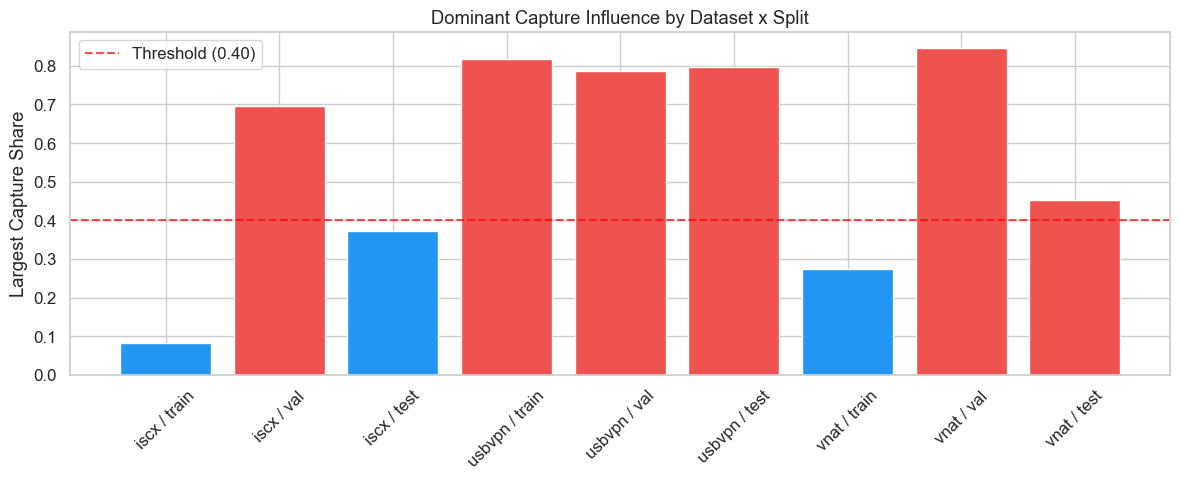


Bars exceeding the red threshold indicate splits where evaluation
may depend heavily on the characteristics of a single capture.


In [8]:
# -- Plot: largest capture share -------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5))
dom_df["ds_split"] = dom_df["dataset"] + " / " + dom_df["split"]
colors = ["#EF5350" if v > 0.4 else "#2196F3" for v in dom_df["largest_capture_share"]]
ax.bar(dom_df["ds_split"], dom_df["largest_capture_share"], color=colors)
ax.axhline(0.4, ls="--", color="red", alpha=0.7, label="Threshold (0.40)")
ax.set_ylabel("Largest Capture Share")
ax.set_title("Dominant Capture Influence by Dataset x Split")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

print("\nBars exceeding the red threshold indicate splits where evaluation")
print("may depend heavily on the characteristics of a single capture.")

---
## Section 5 — Minority support stability test

In [9]:
# -- Minority (VPN) support per split --------------------------------------
minority_rows = []
for (ds, sp), grp in df.groupby(["dataset", "split"]):
    vpn_flows = int((grp["label"] == 1).sum())
    vpn_captures = int(grp.loc[grp["label"] == 1, "capture_id"].nunique())
    minority_rows.append({
        "dataset": ds,
        "split": sp,
        "vpn_flows": vpn_flows,
        "vpn_captures": vpn_captures,
        "flag_low_flows": vpn_flows < 100,
        "flag_low_captures": vpn_captures < 3,
    })

minority_df = pd.DataFrame(minority_rows)
minority_df["_order"] = minority_df["split"].map(split_order)
minority_df = minority_df.sort_values(["dataset", "_order"]).drop(columns="_order").reset_index(drop=True)

display(minority_df)

fragile = minority_df[minority_df["flag_low_flows"] | minority_df["flag_low_captures"]]
if len(fragile) > 0:
    print("\nWARNING: The following splits may be statistically fragile:")
    display(fragile)
    print("Splits with very few VPN flows or VPN captures may produce unreliable")
    print("performance estimates (high variance in recall, precision).")
else:
    print("\nAll splits have adequate minority-class support (>=100 VPN flows, >=3 VPN captures).")

,dataset,split,vpn_flows,vpn_captures,flag_low_flows,flag_low_captures
0,iscx,train,2059,24,False,False
1,iscx,val,440,3,False,False
2,iscx,test,444,4,False,False
3,usbvpn,train,5905,19,False,False
4,usbvpn,val,1282,3,False,False
5,usbvpn,test,1269,8,False,False
6,vnat,train,262,26,False,False
7,vnat,val,57,1,True,True
8,vnat,test,55,55,True,False


,dataset,split,vpn_flows,vpn_captures,flag_low_flows,flag_low_captures
7,vnat,val,57,1,True,True
8,vnat,test,55,55,True,False


Splits with very few VPN flows or VPN captures may produce unreliable
performance estimates (high variance in recall, precision).


---
## Section 6 — Capture size skew analysis

In [10]:
# -- Capture size skew per dataset x label ---------------------------------
cap_by_label = (
    cap_summary.groupby(["dataset", "label"])
    .agg(
        number_of_captures=("capture_id", "nunique"),
        min_flows_per_capture=("n_flows", "min"),
        median_flows_per_capture=("n_flows", "median"),
        mean_flows_per_capture=("n_flows", "mean"),
        max_flows_per_capture=("n_flows", "max"),
        std_flows_per_capture=("n_flows", "std"),
        total_flows=("n_flows", "sum"),
    )
    .reset_index()
)
cap_by_label["coefficient_of_variation"] = (
    cap_by_label["std_flows_per_capture"] / cap_by_label["mean_flows_per_capture"]
).round(3)
cap_by_label["largest_capture_fraction"] = (
    cap_by_label["max_flows_per_capture"] / cap_by_label["total_flows"]
).round(4)

for c in ["median_flows_per_capture", "mean_flows_per_capture", "std_flows_per_capture"]:
    cap_by_label[c] = cap_by_label[c].round(2)

display(cap_by_label.drop(columns="total_flows"))

print("\nHigh coefficient of variation or large 'largest_capture_fraction'")
print("suggests that greedy splitting may be sensitive to capture size imbalance.")

,dataset,label,number_of_captures,min_flows_per_capture,median_flows_per_capture,mean_flows_per_capture,max_flows_per_capture,std_flows_per_capture,coefficient_of_variation,largest_capture_fraction
0,iscx,0,109,1,36.0,81.27,1231,153.50,1.889,0.1390
1,iscx,1,31,2,67.0,94.94,309,84.68,0.892,0.1050
2,usbvpn,0,5,36,57.0,8849.60,41035,18039.68,2.038,0.9274
3,usbvpn,1,30,1,5.0,281.87,1710,517.75,1.837,0.2022
4,vnat,0,83,1,14.0,93.17,1552,277.09,2.974,0.2007
5,vnat,1,82,1,1.0,4.56,125,19.25,4.221,0.3342



High coefficient of variation or large 'largest_capture_fraction'
suggests that greedy splitting may be sensitive to capture size imbalance.


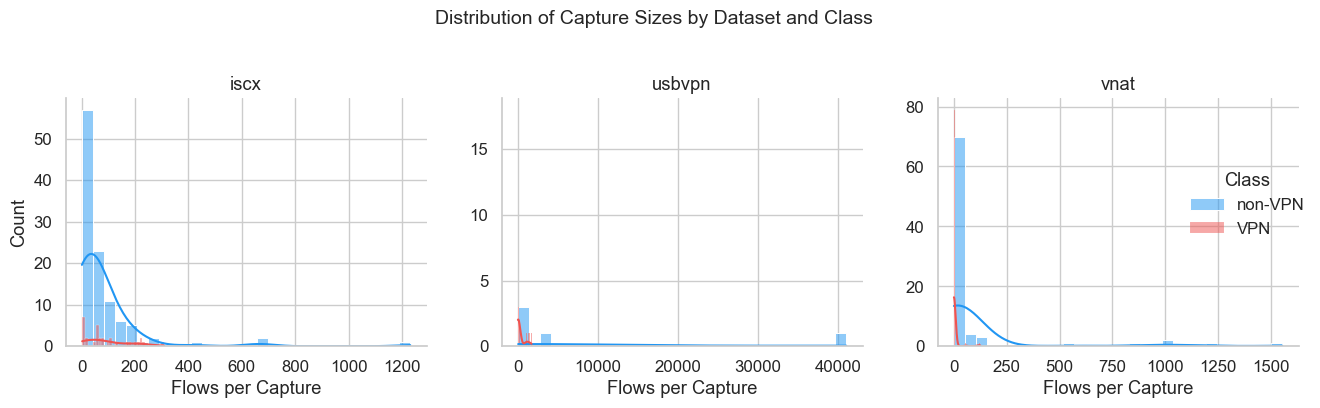

In [11]:
# -- Plot: distribution of capture sizes -----------------------------------
g = sns.FacetGrid(
    cap_summary.assign(label_str=cap_summary["label"].map({0: "non-VPN", 1: "VPN"})),
    col="dataset",
    hue="label_str",
    col_wrap=min(3, cap_summary["dataset"].nunique()),
    height=4,
    sharex=False,
    sharey=False,
    palette={"non-VPN": "#2196F3", "VPN": "#EF5350"},
)
g.map(sns.histplot, "n_flows", kde=True, alpha=0.5, bins=30)
g.add_legend(title="Class")
g.set_titles("{col_name}")
g.set_xlabels("Flows per Capture")
g.set_ylabels("Count")
plt.suptitle("Distribution of Capture Sizes by Dataset and Class", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

---
## Section 7 — Multi-seed split stability experiment

In [12]:
# -- Re-run splitting for seeds 42-61 -------------------------------------
from src.clean_pipeline.splitter import CleanSplitConfig, make_clean_split

SEEDS = list(range(42, 62))  # 42 through 61 inclusive

# Prepare a copy WITHOUT the split column
df_nosplit = df.drop(columns="split").copy()

seed_records = []
for seed in SEEDS:
    cfg = CleanSplitConfig(seed=seed)
    with contextlib.redirect_stdout(io.StringIO()):
        tmp = make_clean_split(df_nosplit.copy(), cfg)

    for (ds, sp), grp in tmp.groupby(["dataset", "split"]):
        seed_records.append({
            "seed": seed,
            "dataset": ds,
            "split": sp,
            "vpn_flows": int((grp["label"] == 1).sum()),
            "nonvpn_flows": int((grp["label"] == 0).sum()),
            "n_captures": int(grp["capture_id"].nunique()),
            "vpn_ratio": float((grp["label"] == 1).mean()),
        })

seed_df = pd.DataFrame(seed_records)
print(f"Completed splitting for {len(SEEDS)} seeds.")
print(f"Total records: {len(seed_df)}")

Completed splitting for 20 seeds.
Total records: 180


In [13]:
# -- Aggregate across seeds ------------------------------------------------
agg_cols = ["vpn_flows", "nonvpn_flows", "n_captures", "vpn_ratio"]
seed_agg = (
    seed_df.groupby(["dataset", "split"])[agg_cols]
    .agg(["mean", "std", "min", "max"])
)
seed_agg.columns = ["_".join(c) for c in seed_agg.columns]
seed_agg = seed_agg.reset_index()

seed_agg["_order"] = seed_agg["split"].map(split_order)
seed_agg = seed_agg.sort_values(["dataset", "_order"]).drop(columns="_order").reset_index(drop=True)

for c in seed_agg.columns:
    if seed_agg[c].dtype == float:
        seed_agg[c] = seed_agg[c].round(4)

display(seed_agg)

print("\nLow standard deviations indicate that split composition is stable")
print("across random seeds. High std suggests sensitivity to seed choice.")

,dataset,split,vpn_flows_mean,vpn_flows_std,vpn_flows_min,vpn_flows_max,nonvpn_flows_mean,nonvpn_flows_std,nonvpn_flows_min,nonvpn_flows_max,n_captures_mean,n_captures_std,n_captures_min,n_captures_max,vpn_ratio_mean,vpn_ratio_std,vpn_ratio_min,vpn_ratio_max
0,iscx,train,2059.90,0.9679,2058,2061,6201.0,0.0,6201,6201,118.60,5.0095,105,125,0.2494,0.0001,0.2492,0.2495
1,iscx,val,441.70,1.1286,440,444,1329.0,0.0,1329,1329,11.30,3.8539,7,23,0.2494,0.0005,0.2487,0.2504
2,iscx,test,441.40,1.1877,440,444,1328.0,0.0,1328,1328,10.10,2.6537,7,17,0.2495,0.0005,0.2489,0.2506
3,usbvpn,train,5913.80,8.4517,5892,5919,44161.0,0.0,44161,44161,15.55,4.2485,11,24,0.1181,0.0001,0.1177,0.1182
4,usbvpn,val,1268.85,7.9158,1259,1283,36.0,0.0,36,36,10.75,5.7936,4,20,0.9724,0.0002,0.9722,0.9727
5,usbvpn,test,1273.35,11.4353,1255,1298,51.0,0.0,51,51,8.70,6.0359,4,20,0.9615,0.0003,0.9609,0.9622
6,vnat,train,262.00,0.0000,262,262,5413.0,0.0,5413,5413,78.45,26.8710,33,102,0.0462,0.0000,0.0462,0.0462
7,vnat,val,56.10,1.0208,55,57,1160.0,0.0,1160,1160,37.85,33.2063,4,124,0.0461,0.0008,0.0453,0.0468
8,vnat,test,55.90,1.0208,55,57,1160.0,0.0,1160,1160,48.70,36.2013,4,121,0.0460,0.0008,0.0453,0.0468



Low standard deviations indicate that split composition is stable
across random seeds. High std suggests sensitivity to seed choice.


---
## Section 8 — Metric sensitivity experiment

In [14]:
# -- Metric sensitivity across seeds --------------------------------------
# Train a lightweight classifier for each seed and measure metric variance.

META_COLS = {"flow_id", "capture_id", "dataset", "label", "split", "source_file", "app"}
feat_cols = [c for c in df.columns if c not in META_COLS]

RUN_METRIC_EXPERIMENT = len(feat_cols) >= 5

if not RUN_METRIC_EXPERIMENT:
    print("Insufficient feature columns for metric sensitivity experiment. Skipping.")
else:
    print(f"Feature columns available: {len(feat_cols)}")
    print("Running metric sensitivity experiment...")

    try:
        import lightgbm as lgb
        USE_LGBM = True
        print("  Using LightGBM")
    except ImportError:
        USE_LGBM = False
        print("  LightGBM not available, using LogisticRegression")

    from sklearn.metrics import roc_auc_score, recall_score, precision_score
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler

    metric_records = []

    for seed_i, seed in enumerate(SEEDS):
        cfg = CleanSplitConfig(seed=seed)
        with contextlib.redirect_stdout(io.StringIO()):
            tmp = make_clean_split(df_nosplit.copy(), cfg)

        train = tmp[tmp["split"] == "train"]
        val   = tmp[tmp["split"] == "val"]
        test  = tmp[tmp["split"] == "test"]

        X_train = train[feat_cols].values.astype(np.float32)
        y_train = train["label"].values.astype(int)
        X_val   = val[feat_cols].values.astype(np.float32)
        y_val   = val["label"].values.astype(int)
        X_test  = test[feat_cols].values.astype(np.float32)
        y_test  = test["label"].values.astype(int)

        # Handle NaN/Inf
        for arr in [X_train, X_val, X_test]:
            np.nan_to_num(arr, copy=False, nan=0.0, posinf=0.0, neginf=0.0)

        if USE_LGBM:
            model = lgb.LGBMClassifier(
                n_estimators=200,
                max_depth=6,
                learning_rate=0.05,
                random_state=seed,
                verbosity=-1,
                n_jobs=-1,
            )
            model.fit(X_train, y_train)
        else:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val   = scaler.transform(X_val)
            X_test  = scaler.transform(X_test)
            model = LogisticRegression(max_iter=2000, random_state=seed, C=1.0)
            model.fit(X_train, y_train)

        # Evaluate on test split
        y_prob = model.predict_proba(X_test)[:, 1]

        # Use validation split to find threshold
        val_prob = model.predict_proba(X_val)[:, 1]
        best_thr, best_f1 = 0.5, 0.0
        for thr in np.arange(0.1, 0.95, 0.01):
            pred_v = (val_prob >= thr).astype(int)
            rec_v = recall_score(y_val, pred_v, zero_division=0)
            prec_v = precision_score(y_val, pred_v, zero_division=0)
            f1_v = 2 * rec_v * prec_v / (rec_v + prec_v) if (rec_v + prec_v) > 0 else 0.0
            if f1_v > best_f1:
                best_f1 = f1_v
                best_thr = thr

        y_pred = (y_prob >= best_thr).astype(int)

        auc = roc_auc_score(y_test, y_prob) if len(np.unique(y_test)) > 1 else float("nan")
        rec = recall_score(y_test, y_pred, zero_division=0)
        prec = precision_score(y_test, y_pred, zero_division=0)
        fpr = ((y_pred == 1) & (y_test == 0)).sum() / max((y_test == 0).sum(), 1)

        metric_records.append({
            "seed": seed,
            "threshold": round(best_thr, 3),
            "roc_auc": round(auc, 4),
            "recall": round(rec, 4),
            "precision": round(prec, 4),
            "fpr": round(fpr, 4),
        })
        print(f"  Seed {seed}: AUC={auc:.4f}, Recall={rec:.4f}, FPR={fpr:.4f}")

    metrics_df = pd.DataFrame(metric_records)
    print("\nPer-seed metrics:")
    display(metrics_df)

    print("\nAggregated metric statistics:")
    display(metrics_df.describe().round(4))

Feature columns available: 25
Running metric sensitivity experiment...
  Using LightGBM


C:\Users\scoti\PycharmProjects\ai-vpn-firewall\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\scoti\PycharmProjects\ai-vpn-firewall\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Seed 42: AUC=0.9943, Recall=0.9459, FPR=0.0051


C:\Users\scoti\PycharmProjects\ai-vpn-firewall\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\scoti\PycharmProjects\ai-vpn-firewall\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Seed 43: AUC=0.9981, Recall=0.9899, FPR=0.0811


...

C:\Users\scoti\PycharmProjects\ai-vpn-firewall\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\scoti\PycharmProjects\ai-vpn-firewall\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Seed 61: AUC=0.9948, Recall=0.9534, FPR=0.0130

Per-seed metrics:


,seed,threshold,roc_auc,recall,precision,fpr
0,42,0.33,0.9943,0.9459,0.9922,0.0051
1,43,0.11,0.9981,0.9899,0.8950,0.0811
2,44,0.11,0.9973,0.9465,0.9737,0.0181
3,45,0.10,0.9685,0.5383,0.9743,0.0098
4,46,0.47,0.9963,0.9173,0.9975,0.0016
5,47,0.10,0.9922,0.9402,0.9302,0.0492
6,48,0.10,0.9874,0.9178,0.9617,0.0252
7,49,0.10,0.9862,0.9411,0.8675,0.1000
8,50,0.27,0.9161,0.4030,0.8850,0.0362
9,51,0.31,0.9942,0.9199,0.9904,0.0063



Aggregated metric statistics:


,seed,threshold,roc_auc,recall,precision,fpr
count,20.0000,20.0000,20.0000,20.0000,20.0000,20.0000
mean,51.5000,0.2190,0.9878,0.8715,0.9626,0.0237
std,5.9161,0.1376,0.0190,0.1878,0.0376,0.0257
min,42.0000,0.1000,0.9161,0.3964,0.8675,0.0016
25%,46.7500,0.1000,0.9871,0.9125,0.9640,0.0089
50%,51.5000,0.1750,0.9946,0.9435,0.9760,0.0148
75%,56.2500,0.2950,0.9975,0.9700,0.9822,0.0252
max,61.0000,0.5700,0.9984,0.9899,0.9975,0.1000


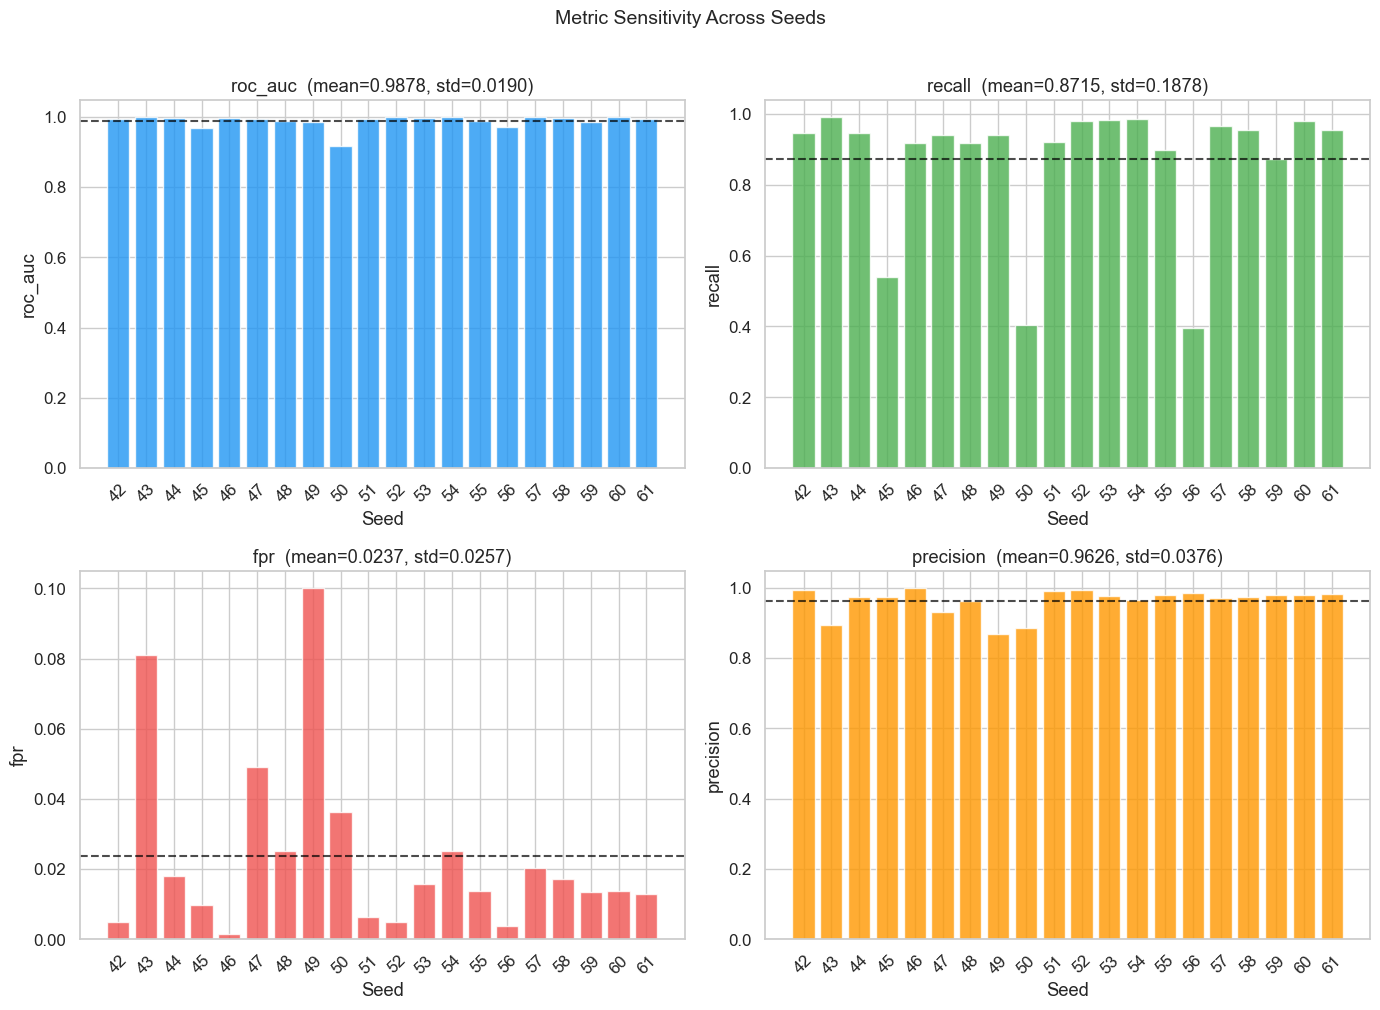


Narrow bars indicate evaluation conclusions are robust to split randomness.
Wide spread suggests split-dependent performance estimates.


In [15]:
# -- Plot: metric variance across seeds ------------------------------------
if RUN_METRIC_EXPERIMENT:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    for ax, col, color in zip(
        axes.flat,
        ["roc_auc", "recall", "fpr", "precision"],
        ["#2196F3", "#4CAF50", "#EF5350", "#FF9800"],
    ):
        ax.bar(metrics_df["seed"].astype(str), metrics_df[col], color=color, alpha=0.8)
        mean_val = metrics_df[col].mean()
        ax.axhline(mean_val, ls="--", color="black", alpha=0.7)
        ax.set_title(f"{col}  (mean={mean_val:.4f}, std={metrics_df[col].std():.4f})")
        ax.set_xlabel("Seed")
        ax.set_ylabel(col)
        ax.tick_params(axis="x", rotation=45)

    plt.suptitle("Metric Sensitivity Across Seeds", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

    print("\nNarrow bars indicate evaluation conclusions are robust to split randomness.")
    print("Wide spread suggests split-dependent performance estimates.")
else:
    print("Metric sensitivity experiment was skipped.")

---
## Section 9 — Automated statistical conclusions

In [16]:
# -- Automated variance classification ------------------------------------
def classify_variation(std_val, thresholds):
    low, high = thresholds
    if std_val <= low:
        return "low_variation"
    elif std_val <= high:
        return "moderate_variation"
    else:
        return "high_variation"

# VPN count variance across seeds
vpn_std_by_split = (
    seed_df.groupby(["dataset", "split"])["vpn_flows"]
    .std()
    .reset_index(name="vpn_flows_std")
)
vpn_std_by_split["vpn_variation"] = vpn_std_by_split["vpn_flows_std"].apply(
    lambda x: classify_variation(x, thresholds=(10.0, 50.0))
)

# Capture count variance across seeds
cap_std_by_split = (
    seed_df.groupby(["dataset", "split"])["n_captures"]
    .std()
    .reset_index(name="n_captures_std")
)
cap_std_by_split["capture_variation"] = cap_std_by_split["n_captures_std"].apply(
    lambda x: classify_variation(x, thresholds=(1.0, 3.0))
)

print("VPN flow count variance across seeds:")
display(vpn_std_by_split)

print("\nCapture count variance across seeds:")
display(cap_std_by_split)

# Metric variance
if RUN_METRIC_EXPERIMENT:
    recall_std = metrics_df["recall"].std()
    fpr_std = metrics_df["fpr"].std()
    auc_std = metrics_df["roc_auc"].std()

    recall_var = classify_variation(recall_std, thresholds=(0.01, 0.03))
    fpr_var = classify_variation(fpr_std, thresholds=(0.005, 0.02))
    auc_var = classify_variation(auc_std, thresholds=(0.005, 0.015))

    print(f"\nRecall std={recall_std:.4f} -> {recall_var}")
    print(f"FPR    std={fpr_std:.4f} -> {fpr_var}")
    print(f"AUC    std={auc_std:.4f} -> {auc_var}")
else:
    recall_var = fpr_var = auc_var = "not_evaluated"
    recall_std = fpr_std = auc_std = float("nan")

# Overall verdict
all_variations = (
    list(vpn_std_by_split["vpn_variation"])
    + list(cap_std_by_split["capture_variation"])
)
if RUN_METRIC_EXPERIMENT:
    all_variations += [recall_var, fpr_var, auc_var]

n_high = sum(1 for v in all_variations if v == "high_variation")
n_mod  = sum(1 for v in all_variations if v == "moderate_variation")

if n_high > 0:
    VERDICT = "UNSTABLE"
elif n_mod > len(all_variations) * 0.3:
    VERDICT = "MODERATELY STABLE"
else:
    VERDICT = "STABLE"

print(f"\n{'='*60}")
print(f"  Split stability verdict: {VERDICT}")
print(f"{'='*60}")

VPN flow count variance across seeds:


,dataset,split,vpn_flows_std,vpn_variation
0,iscx,test,1.187656,low_variation
1,iscx,train,0.967906,low_variation
2,iscx,val,1.128576,low_variation
3,usbvpn,test,11.435287,moderate_variation
4,usbvpn,train,8.451720,low_variation
5,usbvpn,val,7.915840,low_variation
6,vnat,test,1.020836,low_variation
7,vnat,train,0.000000,low_variation
8,vnat,val,1.020836,low_variation



Capture count variance across seeds:


,dataset,split,n_captures_std,capture_variation
0,iscx,test,2.653697,moderate_variation
1,iscx,train,5.009465,high_variation
2,iscx,val,3.853911,high_variation
3,usbvpn,test,6.035858,high_variation
4,usbvpn,train,4.248529,high_variation
5,usbvpn,val,5.793599,high_variation
6,vnat,test,36.201338,high_variation
7,vnat,train,26.870988,high_variation
8,vnat,val,33.206333,high_variation



Recall std=0.1878 -> high_variation
FPR    std=0.0257 -> high_variation
AUC    std=0.0190 -> high_variation

  Split stability verdict: UNSTABLE


---
## Section 10 — Generate thesis-ready textual report

In [17]:
# -- Build structured Markdown report --------------------------------------

def _fmt(val, fmt=".4f"):
    if isinstance(val, float) and np.isnan(val):
        return "N/A"
    return f"{val:{fmt}}"

total = len(df)
vpn_total = int((df["label"] == 1).sum())
nonvpn_total = total - vpn_total

max_dom = dom_df["largest_capture_share"].max()
dom_cases = len(dom_df[dom_df["largest_capture_share"] > 0.4])

fragile_count = len(fragile)

mean_vpn_std = vpn_std_by_split["vpn_flows_std"].mean()
mean_cap_std = cap_std_by_split["n_captures_std"].mean()

lines = []
lines.append("# Split Stability Audit Report")
lines.append("")
lines.append("**Generated automatically by `split_stability_audit.ipynb`**")
lines.append("")
lines.append("---")
lines.append("")

# Section: Dataset imbalance
lines.append("## 1. Overall Dataset Imbalance")
lines.append("")
lines.append(f"- Total flows: **{total:,}**")
lines.append(f"- VPN flows: **{vpn_total:,}** ({vpn_total/total*100:.2f}%)")
lines.append(f"- Non-VPN flows: **{nonvpn_total:,}** ({nonvpn_total/total*100:.2f}%)")
lines.append(f"- Datasets: **{sorted(df['dataset'].unique())}**")
lines.append("")
for ds in sorted(df["dataset"].unique()):
    sub = df[df["dataset"] == ds]
    vpn = (sub["label"] == 1).sum()
    lines.append(f"  - {ds}: {len(sub):,} flows, VPN={vpn:,} ({vpn/len(sub)*100:.1f}%)")
lines.append("")

# Section: Per-split class support
lines.append("## 2. Per-Split Class Support")
lines.append("")
lines.append("| Dataset | Split | Flows | VPN | non-VPN | VPN Ratio | Captures |")
lines.append("|---------|-------|------:|----:|--------:|----------:|---------:|")
for _, row in flow_stats.iterrows():
    lines.append(
        f"| {row['dataset']} | {row['split']} | {int(row['n_flows']):,} "
        f"| {int(row['vpn_flows']):,} | {int(row['nonvpn_flows']):,} "
        f"| {row['vpn_ratio']:.4f} | {int(row['n_captures'])} |"
    )
lines.append("")

# Section: Capture dominance
lines.append("## 3. Capture Dominance Assessment")
lines.append("")
lines.append(f"- Maximum single-capture flow share: **{max_dom:.4f}**")
lines.append(f"- Splits exceeding 40% threshold: **{dom_cases}**")
lines.append("")
if dom_cases > 0:
    lines.append("Some splits are heavily influenced by a single capture, which may ")
    lines.append("bias evaluation metrics toward the characteristics of that capture.")
else:
    lines.append("No split exhibits excessive dominance by a single capture. ")
    lines.append("Evaluation results are distributed across multiple independent captures.")
lines.append("")

# Section: Minority support
lines.append("## 4. Minority Support Stability Assessment")
lines.append("")
lines.append(f"- Splits with < 100 VPN flows or < 3 VPN captures: **{fragile_count}**")
lines.append("")
if fragile_count > 0:
    lines.append("Some validation or test splits contain insufficient minority-class ")
    lines.append("support, which may render recall and precision estimates unreliable.")
else:
    lines.append("All splits contain adequate minority-class support for reliable evaluation.")
lines.append("")

# Section: Seed sensitivity
lines.append("## 5. Seed Sensitivity Assessment")
lines.append("")
lines.append(f"- Seeds evaluated: **{len(SEEDS)}** ({min(SEEDS)}-{max(SEEDS)})")
lines.append(f"- Mean VPN flow std across splits: **{mean_vpn_std:.2f}**")
lines.append(f"- Mean capture count std across splits: **{mean_cap_std:.2f}**")
lines.append("")

# Section: Metric sensitivity
lines.append("## 6. Metric Sensitivity Assessment")
lines.append("")
if RUN_METRIC_EXPERIMENT:
    lines.append(f"- ROC-AUC std: **{_fmt(auc_std)}** ({auc_var})")
    lines.append(f"- Recall std: **{_fmt(recall_std)}** ({recall_var})")
    lines.append(f"- FPR std: **{_fmt(fpr_std)}** ({fpr_var})")
    lines.append(f"- Precision std: **{_fmt(metrics_df['precision'].std())}**")
    lines.append("")
    lines.append(f"Mean ROC-AUC: {metrics_df['roc_auc'].mean():.4f}, ")
    lines.append(f"Mean Recall: {metrics_df['recall'].mean():.4f}, ")
    lines.append(f"Mean FPR: {metrics_df['fpr'].mean():.4f}")
else:
    lines.append("Metric sensitivity experiment was not executed (insufficient feature columns).")
lines.append("")

# Final conclusion
lines.append("## 7. Final Methodological Conclusion")
lines.append("")
lines.append(f"**Split stability verdict: {VERDICT}**")
lines.append("")

if VERDICT == "STABLE":
    lines.append(
        "The capture-level splitting strategy preserves class proportions across "
        "partitions with limited variation across seeds, suggesting that downstream "
        "evaluation metrics are not strongly dependent on random split initialization. "
        "The greedy assignment algorithm effectively distributes flows across train, "
        "validation, and test partitions while maintaining capture integrity. "
        "Performance estimates derived from this splitting strategy may be considered "
        "reliable for cross-dataset generalization assessment."
    )
elif VERDICT == "MODERATELY STABLE":
    lines.append(
        "The split composition exhibits moderate variability across seeds. "
        "While the capture-level splitting strategy generally preserves class "
        "proportions, some partitions show non-trivial sensitivity to the random "
        "seed, particularly for minority-class captures. Performance estimates "
        "should be interpreted with awareness that moderate variation in split "
        "composition may influence evaluation conclusions. Reporting results "
        "across multiple seeds is recommended."
    )
else:
    lines.append(
        "The split composition exhibits substantial instability due to uneven "
        "minority-class capture distribution, indicating that performance estimates "
        "should be interpreted with caution. The greedy splitting algorithm is "
        "sensitive to the random seed in the presence of highly skewed capture sizes. "
        "Multi-seed averaging or alternative splitting strategies (e.g., stratified "
        "k-fold at the capture level) should be considered to obtain robust "
        "performance estimates."
    )
lines.append("")
lines.append("---")
lines.append("")
lines.append("*Report generated automatically. Do not edit manually.*")

report_text = "\n".join(lines)

# Save report
report_path = REPORT_DIR / "split_stability_report.md"
report_path.parent.mkdir(parents=True, exist_ok=True)
report_path.write_text(report_text, encoding="utf-8")

print(f"\nReport saved to: {report_path}")
print(f"\n{'='*60}")
print(f"  FINAL VERDICT: {VERDICT}")
print(f"{'='*60}")


Report saved to: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\clean_pipeline\split_stability_report.md

  FINAL VERDICT: UNSTABLE


---
## Section 11 — Threshold Stability Across Seeds

**Purpose:** Formally audit threshold selection stability. The per-seed
best-F1 threshold is treated as a first-class stability metric, comparable
to recall, FPR, and AUC.

This extends the metric sensitivity analysis from Section 8 by adding
threshold-specific statistics, visualizations, and a stability verdict.

In [18]:
# ── 11a. Threshold statistics ────────────────────────────────────
if RUN_METRIC_EXPERIMENT:
    thr_vals = metrics_df["threshold"].values
    thr_mean   = float(np.mean(thr_vals))
    thr_std    = float(np.std(thr_vals, ddof=1)) if len(thr_vals) > 1 else 0.0
    thr_min    = float(np.min(thr_vals))
    thr_max    = float(np.max(thr_vals))
    thr_median = float(np.median(thr_vals))
    thr_p25    = float(np.percentile(thr_vals, 25))
    thr_p75    = float(np.percentile(thr_vals, 75))
    thr_iqr    = thr_p75 - thr_p25
    thr_cv     = thr_std / thr_mean if thr_mean > 0 else float("nan")

    # Classify threshold stability
    if thr_cv < 0.05 and thr_std < 0.02:
        thr_stability_verdict = "STABLE"
    elif thr_cv < 0.15 and thr_std < 0.05:
        thr_stability_verdict = "MODERATELY STABLE"
    else:
        thr_stability_verdict = "FRAGILE"

    print("Threshold Stability Across Seeds:")
    print(f"  Mean:   {thr_mean:.4f}")
    print(f"  Std:    {thr_std:.4f}")
    print(f"  CV:     {thr_cv:.4f}")
    print(f"  Min:    {thr_min:.4f}")
    print(f"  Max:    {thr_max:.4f}")
    print(f"  Median: {thr_median:.4f}")
    print(f"  IQR:    {thr_iqr:.4f}")
    print(f"  Verdict: {thr_stability_verdict}")

    # Extended summary table including threshold
    ext_summary_rows = []
    for met_name in ["threshold", "roc_auc", "recall", "precision", "fpr"]:
        vals = metrics_df[met_name].values
        m = float(np.mean(vals))
        s = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
        cv = s / m if m > 0 else float("nan")
        if met_name == "threshold":
            verd = thr_stability_verdict
        else:
            verd = classify_variation(s, (0.01, 0.03) if met_name in ("recall","precision")
                                       else (0.005, 0.02) if met_name == "fpr"
                                       else (0.005, 0.015))
        ext_summary_rows.append({
            "metric": met_name,
            "mean": round(m, 4), "std": round(s, 4),
            "min": round(float(np.min(vals)), 4),
            "max": round(float(np.max(vals)), 4),
            "cv": round(cv, 4),
            "verdict": verd,
        })
    ext_summary_df = pd.DataFrame(ext_summary_rows)
    print("\nExtended Stability Summary (threshold as first-class metric):")
    display(ext_summary_df)

    # Save artifact
    ext_summary_path = REPORT_DIR / "threshold_stability_summary.csv"
    ext_summary_df.to_csv(ext_summary_path, index=False)
    print(f"\nSaved → {ext_summary_path}")
else:
    print("Metric sensitivity experiment was not executed. Skipping threshold stability.")
    thr_stability_verdict = "not_evaluated"

Threshold Stability Across Seeds:
  Mean:   0.2190
  Std:    0.1376
  CV:     0.6285
  Min:    0.1000
  Max:    0.5700
  Median: 0.1750
  IQR:    0.1950
  Verdict: FRAGILE

Extended Stability Summary (threshold as first-class metric):


,metric,mean,std,min,max,cv,verdict
0,threshold,0.2190,0.1376,0.1000,0.5700,0.6285,FRAGILE
1,roc_auc,0.9878,0.0190,0.9161,0.9984,0.0192,high_variation
2,recall,0.8715,0.1878,0.3964,0.9899,0.2155,high_variation
3,precision,0.9626,0.0376,0.8675,0.9975,0.0390,high_variation
4,fpr,0.0237,0.0257,0.0016,0.1000,1.0838,high_variation



Saved → C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\clean_pipeline\threshold_stability_summary.csv


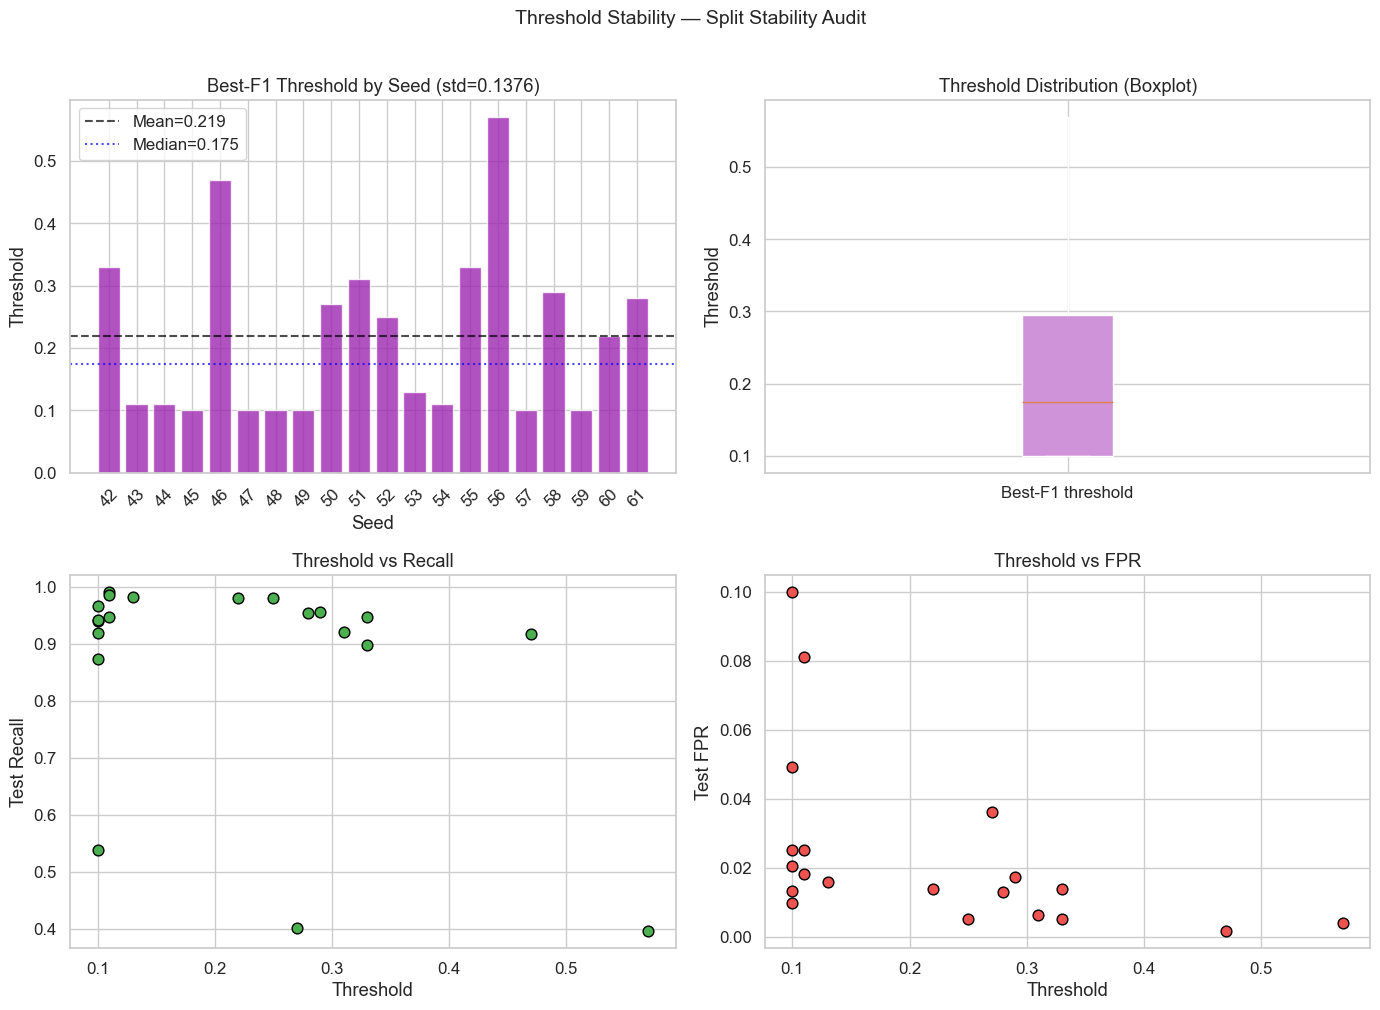

In [19]:
# ── 11b. Threshold stability visualizations ──────────────────────
if RUN_METRIC_EXPERIMENT:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # (1) Threshold by seed
    ax = axes[0, 0]
    ax.bar(metrics_df["seed"].astype(str), metrics_df["threshold"],
           color="#9C27B0", alpha=0.8)
    ax.axhline(thr_mean, ls="--", color="black", alpha=0.7,
               label=f"Mean={thr_mean:.3f}")
    ax.axhline(thr_median, ls=":", color="blue", alpha=0.7,
               label=f"Median={thr_median:.3f}")
    ax.set_title(f"Best-F1 Threshold by Seed (std={thr_std:.4f})")
    ax.set_xlabel("Seed"); ax.set_ylabel("Threshold")
    ax.legend(); ax.tick_params(axis="x", rotation=45)

    # (2) Boxplot
    ax = axes[0, 1]
    bp = ax.boxplot(thr_vals, vert=True, patch_artist=True)
    bp["boxes"][0].set_facecolor("#CE93D8")
    ax.set_title("Threshold Distribution (Boxplot)")
    ax.set_ylabel("Threshold")
    ax.set_xticklabels(["Best-F1 threshold"])

    # (3) Threshold vs Recall
    ax = axes[1, 0]
    ax.scatter(metrics_df["threshold"], metrics_df["recall"],
               c="#4CAF50", s=60, edgecolors="black")
    ax.set_xlabel("Threshold"); ax.set_ylabel("Test Recall")
    ax.set_title("Threshold vs Recall")

    # (4) Threshold vs FPR
    ax = axes[1, 1]
    ax.scatter(metrics_df["threshold"], metrics_df["fpr"],
               c="#EF5350", s=60, edgecolors="black")
    ax.set_xlabel("Threshold"); ax.set_ylabel("Test FPR")
    ax.set_title("Threshold vs FPR")

    plt.suptitle("Threshold Stability — Split Stability Audit",
                 fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("Skipped (no metric experiment).")

### Interpretation — Threshold Stability

The per-seed best-F1 threshold is reported here as a **first-class stability
metric**.  If the threshold coefficient of variation (CV) exceeds ~0.10, or
its standard deviation exceeds ~0.03, the operating point is meaningfully
unstable across random split seeds.

This instability *amplifies* the underlying split-composition variance:
different seeds yield different validation sets → different optimal thresholds
→ different recall / FPR on test.

**Recommendations:**
- Report threshold uncertainty explicitly (mean ± std, CV, IQR).
- Consider using a **median or fixed threshold** across seeds for deployment.
- Do **not** frame threshold stabilization as solving domain shift.

See also: `notebooks/66_splitter_v2_stability_audit.ipynb` Section 6 for a
detailed threshold rule comparison and low-variance threshold selection.

In [20]:
# ── 11c. Update report text with threshold stability section ─────
if RUN_METRIC_EXPERIMENT:
    thr_section = []
    thr_section.append("")
    thr_section.append("## 8. Threshold Stability Across Seeds")
    thr_section.append("")
    thr_section.append(f"- Mean threshold: **{thr_mean:.4f}**")
    thr_section.append(f"- Std threshold:  **{thr_std:.4f}**")
    thr_section.append(f"- CV: **{thr_cv:.4f}**")
    thr_section.append(f"- Range: [{thr_min:.4f}, {thr_max:.4f}]")
    thr_section.append(f"- IQR: **{thr_iqr:.4f}**")
    thr_section.append(f"- **Stability verdict: {thr_stability_verdict}**")
    thr_section.append("")
    thr_section.append("The per-seed best-F1 threshold is included as a first-class ")
    thr_section.append("stability metric. If the threshold is FRAGILE or MODERATELY STABLE, ")
    thr_section.append("downstream metric variance is partly driven by unstable threshold ")
    thr_section.append("selection rather than purely by model discriminative ability.")
    thr_section.append("")
    thr_section.append("**Recommendation:** Use a fixed threshold (median across seeds) ")
    thr_section.append("for deployment, and report threshold uncertainty explicitly.")
    thr_section.append("")

    # Append to existing report text
    report_text_extended = report_text.replace(
        "---\n\n*Report generated automatically.",
        "\n".join(thr_section) + "\n---\n\n*Report generated automatically."
    )

    # Save updated report
    report_path = REPORT_DIR / "split_stability_report.md"
    report_path.write_text(report_text_extended, encoding="utf-8")
    print(f"Updated report saved → {report_path}")
else:
    print("Skipped (no metric experiment).")

Updated report saved → C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\clean_pipeline\split_stability_report.md


In [21]:
# -- Display the generated report inline -----------------------------------
from IPython.display import Markdown, display as ipy_display
ipy_display(Markdown(report_text))

# Split Stability Audit Report

**Generated automatically by `split_stability_audit.ipynb`**

---

## 1. Overall Dataset Imbalance

- Total flows: **72,612**
- VPN flows: **11,773** (16.21%)
- Non-VPN flows: **60,839** (83.79%)
- Datasets: **['iscx', 'usbvpn', 'vnat']**

  - iscx: 11,801 flows, VPN=2,943 (24.9%)
  - usbvpn: 52,704 flows, VPN=8,456 (16.0%)
  - vnat: 8,107 flows, VPN=374 (4.6%)

## 2. Per-Split Class Support

| Dataset | Split | Flows | VPN | non-VPN | VPN Ratio | Captures |
|---------|-------|------:|----:|--------:|----------:|---------:|
| iscx | train | 8,260 | 2,059 | 6,201 | 0.2493 | 123 |
| iscx | val | 1,769 | 440 | 1,329 | 0.2487 | 7 |
| iscx | test | 1,772 | 444 | 1,328 | 0.2506 | 10 |
| usbvpn | train | 50,153 | 5,905 | 44,248 | 0.1177 | 24 |
| usbvpn | val | 1,282 | 1,282 | 0 | 1.0000 | 3 |
| usbvpn | test | 1,269 | 1,269 | 0 | 1.0000 | 8 |
| vnat | train | 5,675 | 262 | 5,413 | 0.0462 | 86 |
| vnat | val | 1,217 | 57 | 1,160 | 0.0468 | 6 |
| vnat | test | 1,215 | 55 | 1,160 | 0.0453 | 73 |

## 3. Capture Dominance Assessment

- Maximum single-capture flow share: **0.8455**
- Splits exceeding 40% threshold: **6**

Some splits are heavily influenced by a single capture, which may 
bias evaluation metrics toward the characteristics of that capture.

## 4. Minority Support Stability Assessment

- Splits with < 100 VPN flows or < 3 VPN captures: **2**

Some validation or test splits contain insufficient minority-class 
support, which may render recall and precision estimates unreliable.

## 5. Seed Sensitivity Assessment

- Seeds evaluated: **20** (42-61)
- Mean VPN flow std across splits: **3.68**
- Mean capture count std across splits: **13.76**

## 6. Metric Sensitivity Assessment

- ROC-AUC std: **0.0190** (high_variation)
- Recall std: **0.1878** (high_variation)
- FPR std: **0.0257** (high_variation)
- Precision std: **0.0376**

Mean ROC-AUC: 0.9878, 
Mean Recall: 0.8715, 
Mean FPR: 0.0237

## 7. Final Methodological Conclusion

**Split stability verdict: UNSTABLE**

The split composition exhibits substantial instability due to uneven minority-class capture distribution, indicating that performance estimates should be interpreted with caution. The greedy splitting algorithm is sensitive to the random seed in the presence of highly skewed capture sizes. Multi-seed averaging or alternative splitting strategies (e.g., stratified k-fold at the capture level) should be considered to obtain robust performance estimates.

---

*Report generated automatically. Do not edit manually.*